#Лабораторная работа №2
##Однослойный перцептрон: реализация, обучение и анализ
###Выполнил:Шилин Василий Б25-507

In [25]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#создание датасета
x, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1
)

#нормализация
scaler = StandardScaler()

scaler.fit(x);

#разбиение на выборки
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y,
    test_size = 0.3,
    stratify=y,
    random_state=42
)


##Реализация Перцептрона

In [26]:
import numpy as np

class Perceptron:
  def __init__(self, seed=42):
    np.random.seed(seed)

    self.w = np.random.randn(2) * 1e-2
    self.b = 0.0

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def forward(self, X):
      z = X @ self.w + self.b
      return self.sigmoid(z)

  def compute_loss(self, y_true, y_pred):
      y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)# чтобы не выдавало бессконечности
      loss = - np.mean(y_true * np.log(y_pred) + (1 - y_true)*np.log(1 - y_pred))
      return loss

  def fit(self, X_train, Y_train, X_val, Y_val, epochs=100, lr=0.01, batch_size=64):
    train_losses = []
    val_losses = []
    n_samples = X_train.shape[0]

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuffled = X_train[perm]
        Y_shuffled = Y_train[perm]

        for i in range(0, n_samples, batch_size):
          X_batch = X_shuffled[i : i + batch_size]
          Y_batch = Y_shuffled[i : i + batch_size]
          m = X_batch.shape[0]

          Y_pred = self.forward(X_batch)

          error = Y_pred - Y_batch
          dw = 1/m * (X_batch.T @ error)
          db = 1/m * np.sum(error)

          self.w = self.w - lr * dw
          self.b = self.b - lr * db


          train_pred = self.forward(X_train)
          val_pred = self.forward(X_test)

        train_losses.append(self.compute_loss(Y_train, train_pred))
        val_losses.append(self.compute_loss(Y_val, val_pred))

        if (epoch + 1) % 10 == 0 or epoch == 0:
              print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
    return train_losses, val_losses

  def predict(self, X):
    return (self.forward(X) >= 0.5).astype(int)


In [27]:
model = Perceptron(seed=42)
train_losses, val_losses = model.fit(
    X_train, Y_train,
    X_test, Y_test,
    epochs=100,
    lr=0.1,
    batch_size=32
)

Epoch 1/100 | Train Loss: 0.5144 | Val Loss: 0.5195
Epoch 10/100 | Train Loss: 0.3485 | Val Loss: 0.3374
Epoch 20/100 | Train Loss: 0.3356 | Val Loss: 0.3164
Epoch 30/100 | Train Loss: 0.3325 | Val Loss: 0.3091
Epoch 40/100 | Train Loss: 0.3315 | Val Loss: 0.3056
Epoch 50/100 | Train Loss: 0.3311 | Val Loss: 0.3037
Epoch 60/100 | Train Loss: 0.3309 | Val Loss: 0.3026
Epoch 70/100 | Train Loss: 0.3309 | Val Loss: 0.3020
Epoch 80/100 | Train Loss: 0.3308 | Val Loss: 0.3016
Epoch 90/100 | Train Loss: 0.3308 | Val Loss: 0.3014
Epoch 100/100 | Train Loss: 0.3308 | Val Loss: 0.3011


##Визуализация обучения

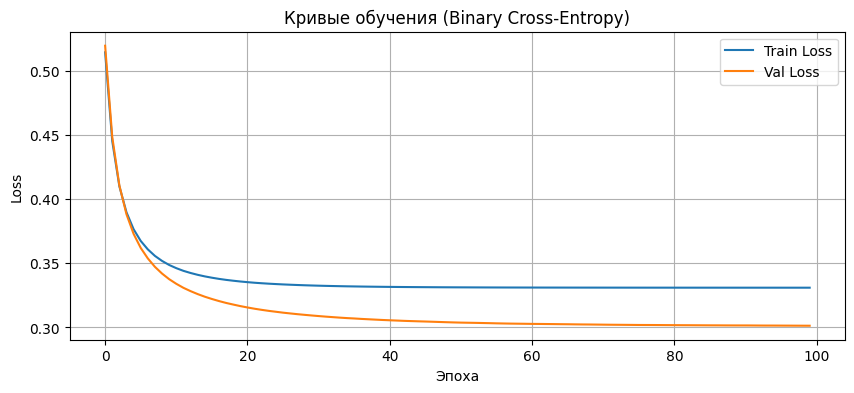


Accuracy (Train): 0.8657
Accuracy (Test):  0.8867


In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Кривые обучения (Binary Cross-Entropy)')

plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

train_acc = np.mean(model.predict(X_train) == Y_train)
test_acc = np.mean(model.predict(X_test) == Y_test)

print(f"\nAccuracy (Train): {train_acc:.4f}")
print(f"Accuracy (Test):  {test_acc:.4f}")

##Визуализация разделяющей границы

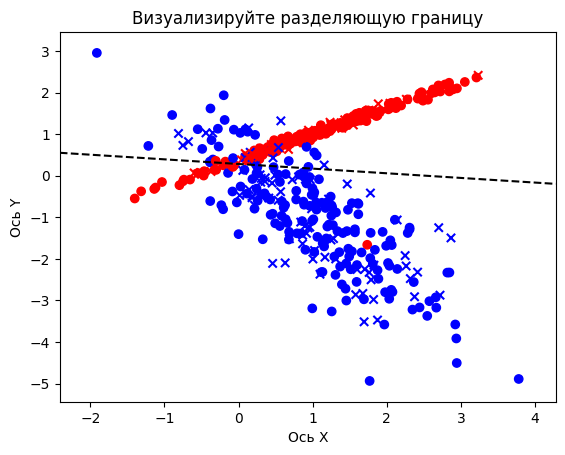

In [29]:
plt.title('Визуализируйте разделяющую границу')
plt.xlabel('Ось X')
plt.ylabel('Ось Y')

plt.scatter(X_train[:,0], X_train[:,1], c=Y_train, cmap="bwr", label="train", marker="o")
plt.scatter(X_test[:,0], X_test[:,1], c=Y_test, cmap="bwr", label='test', marker="x")


x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Вычисление предсказаний
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.forward(grid_points)
Z = Z.reshape(xx.shape)

# Разделяющая граница
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--')

plt.show()

##Эксперименты и анализ

# 1)Влияние скорости обучения

current learning rate = 0.001
Epoch 1/100 | Train Loss: 0.6908 | Val Loss: 0.6911
Epoch 10/100 | Train Loss: 0.6659 | Val Loss: 0.6674
Epoch 20/100 | Train Loss: 0.6412 | Val Loss: 0.6437
Epoch 30/100 | Train Loss: 0.6191 | Val Loss: 0.6225
Epoch 40/100 | Train Loss: 0.5993 | Val Loss: 0.6033
Epoch 50/100 | Train Loss: 0.5816 | Val Loss: 0.5861
Epoch 60/100 | Train Loss: 0.5657 | Val Loss: 0.5705
Epoch 70/100 | Train Loss: 0.5514 | Val Loss: 0.5564
Epoch 80/100 | Train Loss: 0.5384 | Val Loss: 0.5435
Epoch 90/100 | Train Loss: 0.5266 | Val Loss: 0.5318
Epoch 100/100 | Train Loss: 0.5159 | Val Loss: 0.5210
--------------------------------------------------
current learning rate = 0.01
Epoch 1/100 | Train Loss: 0.6659 | Val Loss: 0.6674
Epoch 10/100 | Train Loss: 0.5157 | Val Loss: 0.5208
Epoch 20/100 | Train Loss: 0.4461 | Val Loss: 0.4494
Epoch 30/100 | Train Loss: 0.4111 | Val Loss: 0.4119
Epoch 40/100 | Train Loss: 0.3905 | Val Loss: 0.3890
Epoch 50/100 | Train Loss: 0.3771 | Val Los

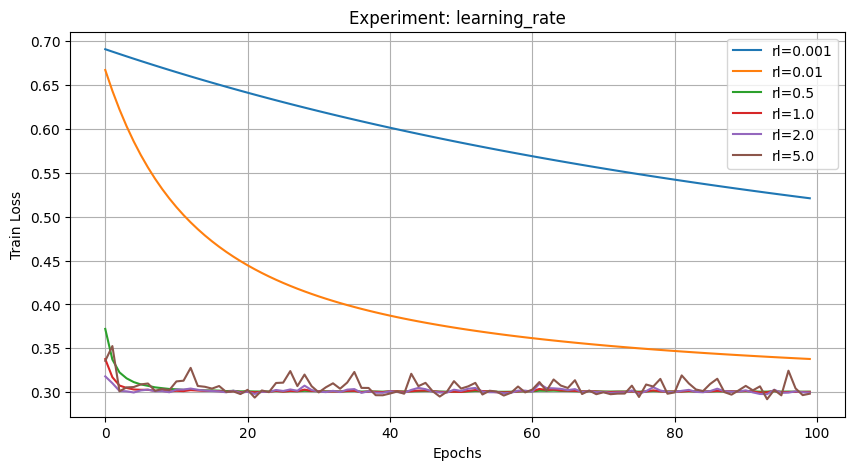

In [30]:
results = []

lr = [0.001, 0.01, 0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(10, 5))

for cur_lr in lr:
  print(f"current learning rate = {cur_lr}")
  model = Perceptron(seed=42)
  train_losses, val_losses = model.fit(
    X_train, Y_train,
    X_test, Y_test,
    epochs=100,
    lr=cur_lr,
    batch_size=32
  )


  results.append({'Exp': 'learning rate', 'param' : cur_lr, 'accuracy' : np.mean(model.predict(X_test) == Y_test), 'final_Train_Loss' : train_losses[-1], 'final_Val_Loss' : val_losses[-1]})

  print(50 * "-")
  plt.plot(val_losses, label=f"rl={cur_lr}")

plt.title(f"Experiment: learning_rate")
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.legend()
plt.grid(True)
plt.show()

##Вывод
Для мальнекого learning rate (0.001) обучения идет очень долго.
Для больших - обучение происходит быстро, но возле минимума просходят коллебания, из-за того ,что мы постоянно "перескакиваем" минимум.

2)Влияние размера батча

current batch size= 1
Epoch 1/100 | Train Loss: 0.3366 | Val Loss: 0.3162
Epoch 10/100 | Train Loss: 0.3318 | Val Loss: 0.2997
Epoch 20/100 | Train Loss: 0.3345 | Val Loss: 0.2988
Epoch 30/100 | Train Loss: 0.3326 | Val Loss: 0.3034
Epoch 40/100 | Train Loss: 0.3326 | Val Loss: 0.2978
Epoch 50/100 | Train Loss: 0.3403 | Val Loss: 0.3065
Epoch 60/100 | Train Loss: 0.3308 | Val Loss: 0.3020
Epoch 70/100 | Train Loss: 0.3319 | Val Loss: 0.2990
Epoch 80/100 | Train Loss: 0.3320 | Val Loss: 0.2991
Epoch 90/100 | Train Loss: 0.3311 | Val Loss: 0.2997
Epoch 100/100 | Train Loss: 0.3315 | Val Loss: 0.2991
--------------------------------------------------
current batch size= 16
Epoch 1/100 | Train Loss: 0.4460 | Val Loss: 0.4494
Epoch 10/100 | Train Loss: 0.3356 | Val Loss: 0.3164
Epoch 20/100 | Train Loss: 0.3315 | Val Loss: 0.3055
Epoch 30/100 | Train Loss: 0.3309 | Val Loss: 0.3028
Epoch 40/100 | Train Loss: 0.3308 | Val Loss: 0.3015
Epoch 50/100 | Train Loss: 0.3308 | Val Loss: 0.3010
Epoc

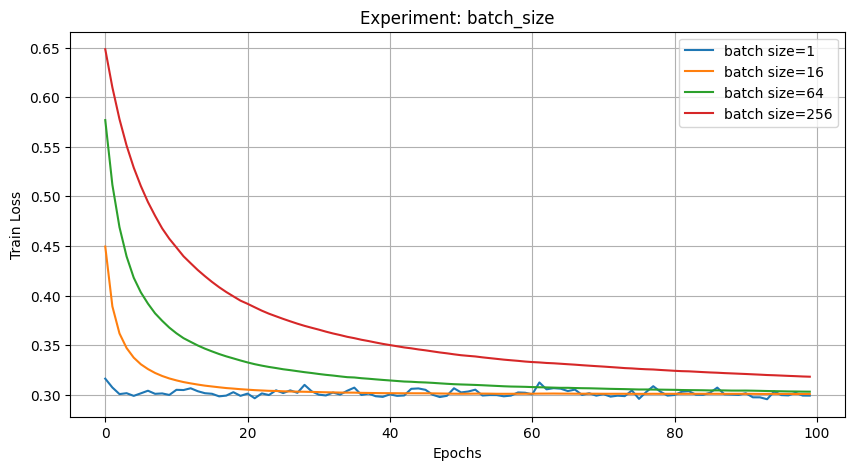

In [31]:
bs = [1, 16, 64, 256]

plt.figure(figsize=(10, 5))

for cur_bs in bs:
  print(f"current batch size= {cur_bs}")
  model = Perceptron(seed=42)
  train_losses, val_losses = model.fit(
    X_train, Y_train,
    X_test, Y_test,
    epochs=100,
    lr=0.1,
    batch_size=cur_bs
  )

  results.append({'Exp': 'batch', 'param' : cur_bs, 'accuracy' : np.mean(model.predict(X_test) == Y_test), 'final_Train_Loss' : train_losses[-1], 'final_Val_Loss' : val_losses[-1]})

  print(50 * "-")
  plt.plot(val_losses, label=f"batch size={cur_bs}")

plt.title(f"Experiment: batch_size")
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.legend()
plt.grid(True)
plt.show()

##Вывод
Batch=1 (SGD) дает зашумленный график loss из-за частых обновлений. Batch=256  дает гладкий график, но требует больше эпох для сходимости.

3)Влияние инициализации весов

current type= 0
Epoch 1/100 | Train Loss: 0.5124 | Val Loss: 0.5175
Epoch 10/100 | Train Loss: 0.3485 | Val Loss: 0.3374
Epoch 20/100 | Train Loss: 0.3356 | Val Loss: 0.3164
Epoch 30/100 | Train Loss: 0.3325 | Val Loss: 0.3091
Epoch 40/100 | Train Loss: 0.3315 | Val Loss: 0.3056
Epoch 50/100 | Train Loss: 0.3311 | Val Loss: 0.3037
Epoch 60/100 | Train Loss: 0.3309 | Val Loss: 0.3026
Epoch 70/100 | Train Loss: 0.3309 | Val Loss: 0.3020
Epoch 80/100 | Train Loss: 0.3308 | Val Loss: 0.3016
Epoch 90/100 | Train Loss: 0.3308 | Val Loss: 0.3014
Epoch 100/100 | Train Loss: 0.3308 | Val Loss: 0.3011
--------------------------------------------------
current type= 1
Epoch 1/100 | Train Loss: 0.3672 | Val Loss: 0.3537
Epoch 10/100 | Train Loss: 0.3356 | Val Loss: 0.3160
Epoch 20/100 | Train Loss: 0.3322 | Val Loss: 0.3084
Epoch 30/100 | Train Loss: 0.3313 | Val Loss: 0.3051
Epoch 40/100 | Train Loss: 0.3310 | Val Loss: 0.3033
Epoch 50/100 | Train Loss: 0.3309 | Val Loss: 0.3023
Epoch 60/100 | Tr

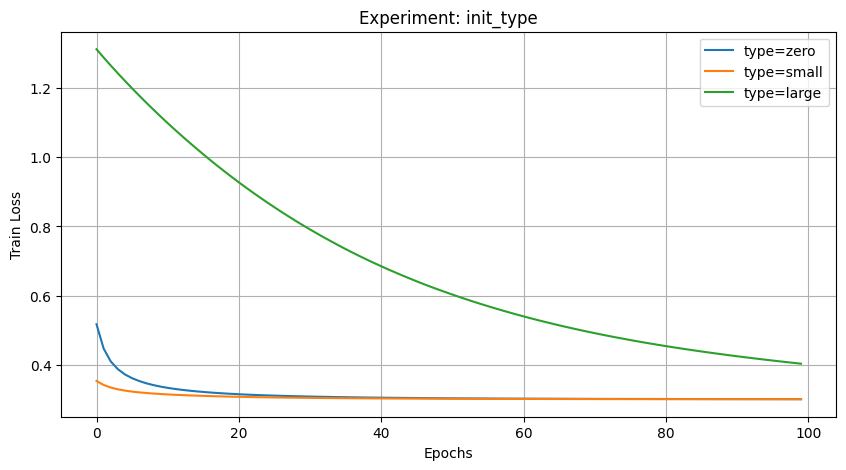

In [32]:
i_type = [0, 1, 10]
name_type = {0 : 'zero', 1 : 'small', 10 : 'large'}

plt.figure(figsize=(10, 5))

for cur_type in i_type:
  print(f"current type= {cur_type}")
  model = Perceptron(seed=42)
  model.w = np.random.randn(2) * cur_type
  train_losses, val_losses = model.fit(
    X_train, Y_train,
    X_test, Y_test,
    epochs=100,
    lr=0.1,
    batch_size=32
  )

  results.append({'Exp': 'init_type', 'param' : name_type[cur_type], 'accuracy' : np.mean(model.predict(X_test) == Y_test), 'final_Train_Loss' : train_losses[-1], 'final_Val_Loss' : val_losses[-1]})

  print(50 * "-")
  plt.plot(val_losses, label=f"type={name_type[cur_type]}")

plt.title(f"Experiment: init_type")
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.legend()
plt.grid(True)
plt.show()

##Вывод
Large init может привести к сатурации (насыщению) сигмоиды, где градиенты близки к нулю. Zero init для перцептрона допустим, но small сходится быстрее.

##Итоговая таблица

In [33]:
import pandas as pd
# Сводная таблица по всем экспериментам задания 1
display(pd.DataFrame(results))

,Exp,param,accuracy,final_Train_Loss,final_Val_Loss
0,learning rate,0.001,0.893333,0.515919,0.521047
1,learning rate,0.01,0.880000,0.348744,0.337745
2,learning rate,0.5,0.886667,0.330826,0.300468
3,learning rate,1.0,0.886667,0.330882,0.300182
4,learning rate,2.0,0.886667,0.331112,0.299463
5,learning rate,5.0,0.886667,0.334968,0.298144
6,batch,1,0.886667,0.331549,0.299068
7,batch,16,0.886667,0.330802,0.300697
8,batch,64,0.886667,0.331054,0.303044
9,batch,256,0.886667,0.336588,0.318138


#Задания на дополнительные баллы
##Задание 1. Собственный генератор данных

Epoch 1/100 | Train Loss: 0.0915 | Val Loss: 0.8206
Epoch 10/100 | Train Loss: 0.0201 | Val Loss: 1.1368
Epoch 20/100 | Train Loss: 0.0132 | Val Loss: 1.2767
Epoch 30/100 | Train Loss: 0.0104 | Val Loss: 1.3709
Epoch 40/100 | Train Loss: 0.0088 | Val Loss: 1.4440
Epoch 50/100 | Train Loss: 0.0077 | Val Loss: 1.5047
Epoch 60/100 | Train Loss: 0.0070 | Val Loss: 1.5569
Epoch 70/100 | Train Loss: 0.0064 | Val Loss: 1.6027
Epoch 80/100 | Train Loss: 0.0059 | Val Loss: 1.6440
Epoch 90/100 | Train Loss: 0.0055 | Val Loss: 1.6818
Epoch 100/100 | Train Loss: 0.0052 | Val Loss: 1.7164
Epoch 1/100 | Train Loss: 0.6930 | Val Loss: 0.6933
Epoch 10/100 | Train Loss: 0.6929 | Val Loss: 0.6935
Epoch 20/100 | Train Loss: 0.6930 | Val Loss: 0.6935
Epoch 30/100 | Train Loss: 0.6930 | Val Loss: 0.6931
Epoch 40/100 | Train Loss: 0.6929 | Val Loss: 0.6932
Epoch 50/100 | Train Loss: 0.6930 | Val Loss: 0.6936
Epoch 60/100 | Train Loss: 0.6929 | Val Loss: 0.6934
Epoch 70/100 | Train Loss: 0.6929 | Val Loss: 0

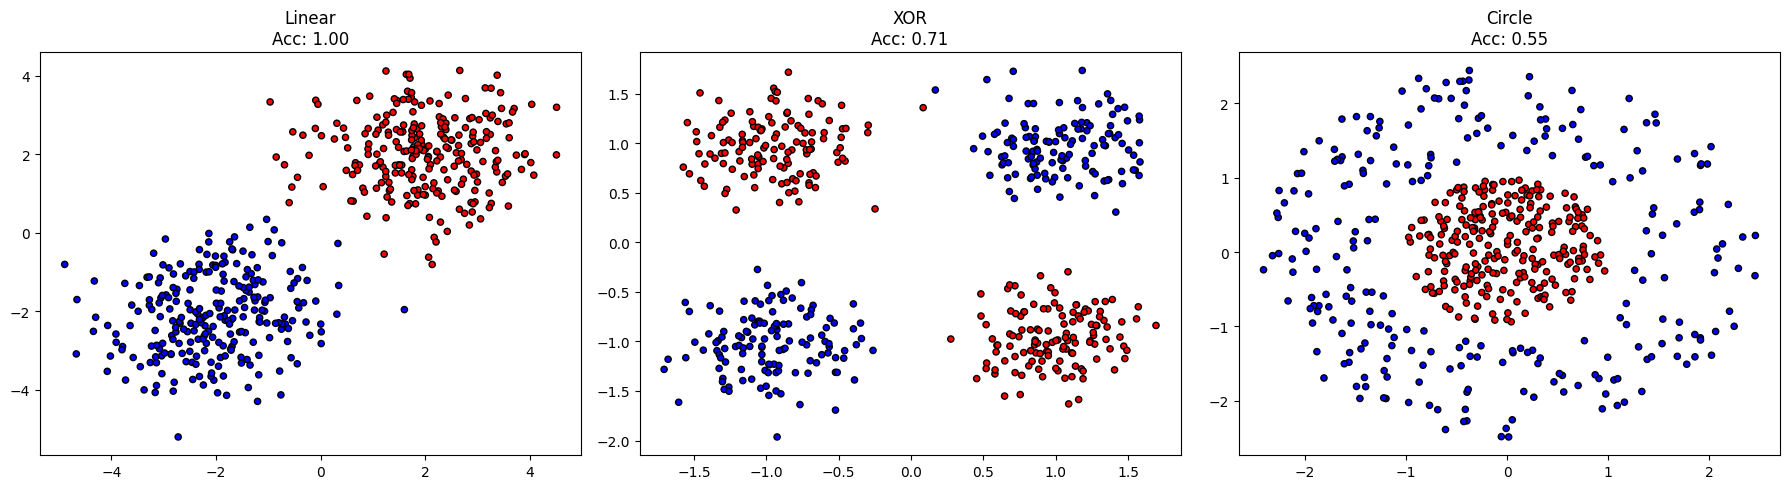

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def generate_linear(n=500, centers=[(-2,-2), (2,2)], cov=[[1,0],[0,1]]):
    n_half = n // 2
    c0 = np.random.multivariate_normal(centers[0], cov, n_half)
    c1 = np.random.multivariate_normal(centers[1], cov, n - n_half)
    X = np.vstack([c0, c1])
    y = np.hstack([np.zeros(n_half), np.ones(n - n_half)])
    return X, y

def generate_xor(n=500, spread=0.3):
    n_q = n // 4

    q1 = np.random.normal([1, 1], spread, (n_q, 2))
    q2 = np.random.normal([-1, -1], spread, (n_q, 2))
    q3 = np.random.normal([-1, 1], spread, (n_q, 2))
    q4 = np.random.normal([1, -1], spread, (n - 3*n_q, 2))
    X = np.vstack([q1, q2, q3, q4])
    y = np.hstack([np.zeros(2*n_q), np.ones(n - 2*n_q)])
    return X, y

def generate_circle(n=500, inner_r=1.0, outer_r=2.5):
    n_half = n // 2

    r_in = np.sqrt(np.random.uniform(0, inner_r**2, n_half))
    theta_in = np.random.uniform(0, 2*np.pi, n_half)
    c1 = np.column_stack([r_in * np.cos(theta_in), r_in * np.sin(theta_in)])

    r_out = np.sqrt(np.random.uniform(inner_r**2 + 0.5, outer_r**2, n - n_half))
    theta_out = np.random.uniform(0, 2*np.pi, n - n_half)
    c0 = np.column_stack([r_out * np.cos(theta_out), r_out * np.sin(theta_out)])
    X = np.vstack([c1, c0])
    y = np.hstack([np.ones(n_half), np.zeros(n - n_half)])
    return X, y

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=20)
    acc = np.mean(model.predict(X) == y)
    ax.set_title(f"{title}\nAcc: {acc:.2f}")

datasets = {
    "Linear": generate_linear(),
    "XOR": generate_xor(),
    "Circle": generate_circle()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, (X, y)) in enumerate(datasets.items()):
    indices = np.random.permutation(len(X))
    split = int(0.7 * len(X))
    train_idx, test_idx = indices[:split], indices[split:]

    model = Perceptron(seed=42)
    model.fit(X[train_idx], y[train_idx], X[test_idx], y[test_idx], epochs=100, lr=0.1, batch_size=16)

    plot_boundary(axes[i], model, X, y, name)

plt.tight_layout()
plt.show()

#Вывод
1. Linear: Данные линейно разделимы, существует гиперплоскость (линия), отделяющая классы.
2. XOR: Классы перемешаны в пространстве признаков так, что любая прямая делит их почти пополам.
3. Circle: Однослойный перцептрон не может выделить замкнутую область. Он всегда проводит прямую.

#Задание 2. Дополнительные функции потерь и регуляризация

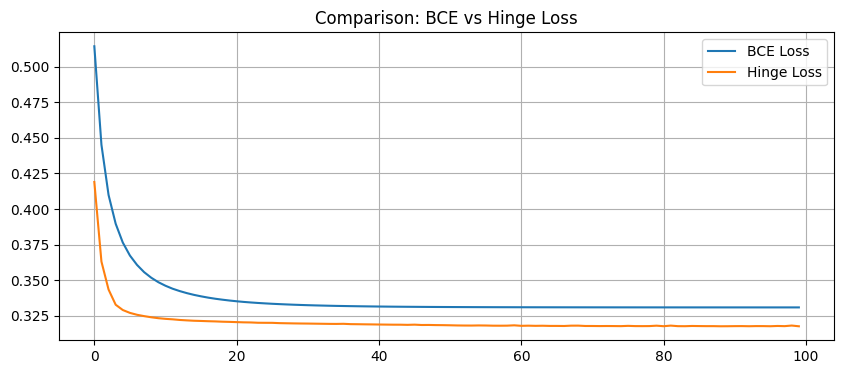

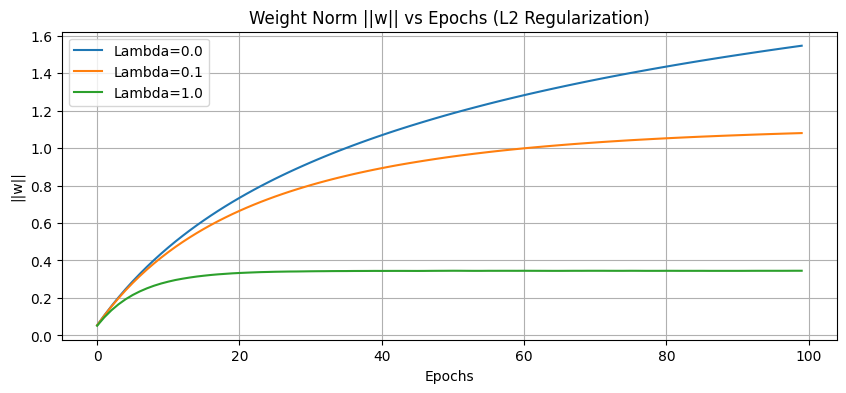

,Lambda,Accuracy,Final_W_Norm
0,0.0,0.880000,1.545945
1,0.1,0.880000,1.079761
2,1.0,0.886667,0.345136


In [35]:
class PerceptronExtended(Perceptron):
    def __init__(self, seed=42, l2_lambda=0.0):
        super().__init__(seed)
        self.l2_lambda = l2_lambda

    def fit_extended(self, X_train, y_train, X_val, y_val, epochs=100, lr=0.1, batch_size=32, loss_type='bce'):
        train_losses = []
        w_norms = []
        n_samples = X_train.shape[0]

        y_t = np.where(y_train == 0, -1, 1) if loss_type == 'hinge' else y_train

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_t[indices]

            for i in range(0, n_samples, batch_size):
                X_b = X_shuffled[i : i + batch_size]
                y_b = y_shuffled[i : i + batch_size]
                m = X_b.shape[0]

                z = X_b @ self.w + self.b

                if loss_type == 'bce':
                    y_hat = self.sigmoid(z)
                    error = y_hat - y_b
                    dw = (1/m) * (X_b.T @ error) + self.l2_lambda * self.w
                    db = (1/m) * np.sum(error)
                else:
                    mask = (y_b * z < 1).astype(float)
                    dw = (1/m) * (X_b.T @ (-mask * y_b)) + self.l2_lambda * self.w
                    db = (1/m) * np.sum(-mask * y_b)

                self.w -= lr * dw
                self.b -= lr * db

            z_all = X_train @ self.w + self.b
            if loss_type == 'bce':
                loss = self.compute_loss(y_train, self.sigmoid(z_all)) + 0.5 * self.l2_lambda * np.sum(self.w**2)
            else:
                loss = np.mean(np.maximum(0, 1 - y_t * z_all)) + 0.5 * self.l2_lambda * np.sum(self.w**2)

            train_losses.append(loss)
            w_norms.append(np.linalg.norm(self.w))

        return train_losses, w_norms

model_bce = PerceptronExtended(seed=42)
model_hinge = PerceptronExtended(seed=42)

bce_l, _ = model_bce.fit_extended(X_train, Y_train, X_test, Y_test, loss_type='bce')
hinge_l, _ = model_hinge.fit_extended(X_train, Y_train, X_test, Y_test, loss_type='hinge')

plt.figure(figsize=(10, 4))
plt.plot(bce_l, label='BCE Loss')
plt.plot(hinge_l, label='Hinge Loss')
plt.title("Comparison: BCE vs Hinge Loss")
plt.legend(); plt.grid(True); plt.show()

lambdas = [0.0, 0.1, 1.0]
plt.figure(figsize=(10, 4))
results_l2 = []

for lb in lambdas:
    model_l2 = PerceptronExtended(seed=42, l2_lambda=lb)
    _, norms = model_l2.fit_extended(X_train, Y_train, X_test, Y_test, lr=0.01)
    acc = np.mean(model_l2.predict(X_test) == Y_test)
    results_l2.append({"Lambda": lb, "Accuracy": acc, "Final_W_Norm": norms[-1]})
    plt.plot(norms, label=f"Lambda={lb}")

plt.title("Weight Norm ||w|| vs Epochs (L2 Regularization)")
plt.ylabel("||w||"); plt.xlabel("Epochs"); plt.legend(); plt.grid(True); plt.show()

display(pd.DataFrame(results_l2))

### Вывод
Hinge Loss обеспечивает более быструю сходимость на начальных этапах за счет постоянного градиента в зоне ошибки, в то время как Binary Cross-Entropy сходится плавнее. L2-регуляризация эффективно ограничивает рост нормы весов (снижая её с 1.54 до 0.34 при λ=1.0), что упрощает модель и повышает её устойчивость к шуму, при этом сохраняя стабильную точность классификации на уровне 88-89%.


Внедрение L2-регуляризации позволяет эффективно контролировать сложность модели: с увеличением коэффициента λ от 0.0 до 1.0 норма весов снижается почти в 4.5 раза (с 1.54 до 0.34), что упрощает разделяющую поверхность и делает модель более устойчивой к шуму без потери качества классификации.

#Задание 3. Метрики качества и анализ ошибок


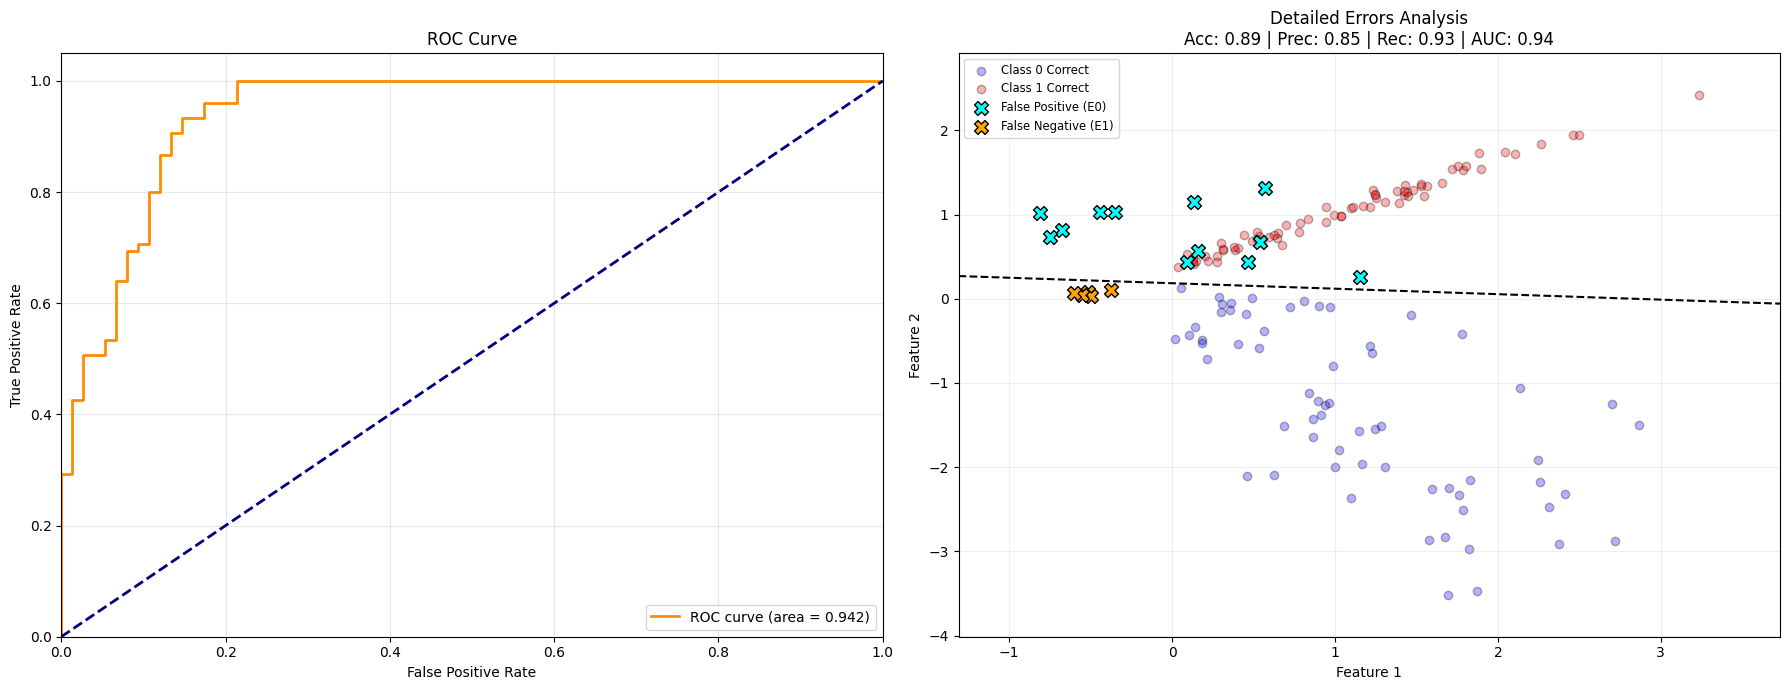

In [36]:
def compute_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def compute_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def compute_f1(y_true, y_pred):
    p = compute_precision(y_true, y_pred)
    r = compute_recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def compute_roc_auc(y_true, y_probs):
    desc_score_indices = np.argsort(y_probs)[::-1]
    y_true_sorted = y_true[desc_score_indices]
    tps = np.cumsum(y_true_sorted)
    fps = np.cumsum(1 - y_true_sorted)
    tpr = tps / tps[-1]
    fpr = fps / fps[-1]
    tpr = np.r_[0, tpr]
    fpr = np.r_[0, fpr]
    auc = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc

y_pred_test = final_model.predict(X_test)
y_probs_test = final_model.forward(X_test)

precision = compute_precision(Y_test, y_pred_test)
recall = compute_recall(Y_test, y_pred_test)
f1 = compute_f1(Y_test, y_pred_test)
accuracy = np.mean(Y_test == y_pred_test)
fpr, tpr, auc_val = compute_roc_auc(Y_test, y_probs_test)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Левый график: ROC-кривая
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_val:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Правый график: Анализ ошибок с разделением по классам
# Правильные ответы
ax[1].scatter(X_test[(Y_test == 0) & (y_pred_test == 0), 0], X_test[(Y_test == 0) & (y_pred_test == 0), 1], c='blue', alpha=0.3, label='Class 0 Correct', edgecolors='k')
ax[1].scatter(X_test[(Y_test == 1) & (y_pred_test == 1), 0], X_test[(Y_test == 1) & (y_pred_test == 1), 1], c='red', alpha=0.3, label='Class 1 Correct', edgecolors='k')
# Ошибки
ax[1].scatter(X_test[(Y_test == 0) & (y_pred_test == 1), 0], X_test[(Y_test == 0) & (y_pred_test == 1), 1], c='cyan', marker='X', s=100, label='False Positive (E0)', edgecolors='k')
ax[1].scatter(X_test[(Y_test == 1) & (y_pred_test == 0), 0], X_test[(Y_test == 1) & (y_pred_test == 0), 1], c='orange', marker='X', s=100, label='False Negative (E1)', edgecolors='k')

# Разделяющая прямая
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = final_model.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[1].contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--')

title_str = (f'Detailed Errors Analysis\nAcc: {accuracy:.2f} | Prec: {precision:.2f} | Rec: {recall:.2f} | AUC: {auc_val:.2f}')
ax[1].set_title(title_str)
ax[1].set_xlabel('Feature 1')
ax[1].set_ylabel('Feature 2')
ax[1].legend(loc='best', fontsize='small')
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Анализ метрик
Итоговое тестирование лучшей модели показало:
* **Accuracy (0.89)**: Высокая общая точность.
* **Precision (0.85)**: Низкий уровень ложноположительных срабатываний.
* **Recall (0.93)**: Модель успешно находит почти все объекты положительного класса.
* **AUC (0.94)**: Отличная разделяющая способность.

На графике ошибок видно, что большинство неверных предсказаний сосредоточено в узкой полосе вдоль разделяющей прямой, где классы пересекаются.

#Задание 4. Исследование сходимости градиентного спуска


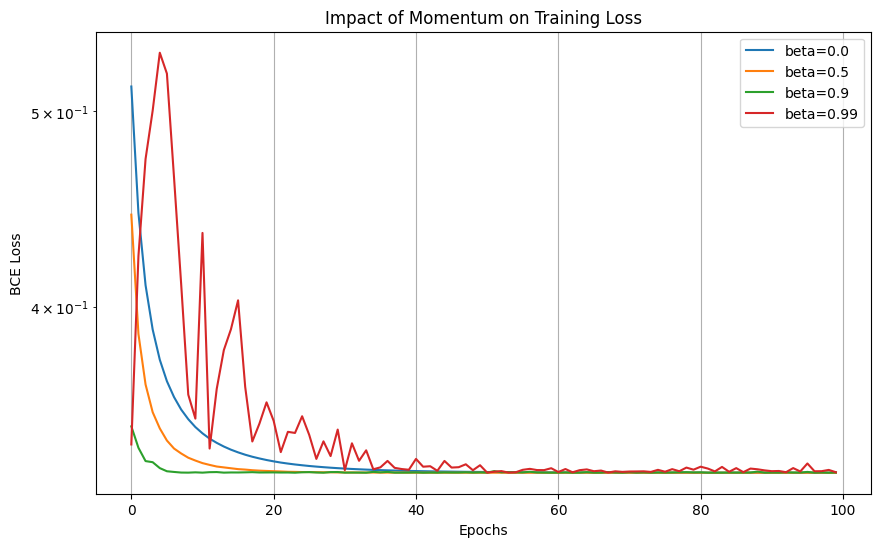

In [37]:
class PerceptronWithMomentum(Perceptron):
    def fit(self, X_train, y_train, X_val, y_val, epochs=100, lr=0.1, batch_size=32, momentum=0.9):
        train_losses = []
        val_losses = []
        n_samples = X_train.shape[0]

        # Инициализация скоростей
        v_w = np.zeros_like(self.w)
        v_b = 0.0

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i : i + batch_size]
                y_batch = y_shuffled[i : i + batch_size]
                m = X_batch.shape[0]

                y_hat = self.forward(X_batch)
                error = y_hat - y_batch

                dw = (1 / m) * (X_batch.T @ error)
                db = (1 / m) * np.sum(error)

                # Momentum update
                v_w = momentum * v_w - lr * dw
                v_b = momentum * v_b - lr * db

                self.w += v_w
                self.b += v_b

            # Logging
            t_loss = self.compute_loss(y_train, self.forward(X_train))
            v_loss = self.compute_loss(y_val, self.forward(X_val))

            train_losses.append(t_loss)
            val_losses.append(v_loss)

            if np.isnan(t_loss):
                break

        return train_losses

# --- Running Momentum Experiment ---
betas = [0.0, 0.5, 0.9, 0.99]
momentum_results = []
plt.figure(figsize=(10, 6))

for beta in betas:
    model_m = PerceptronWithMomentum(seed=42)
    losses = model_m.fit(
        X_train, Y_train, X_test, Y_test,
        epochs=100, lr=0.1, batch_size=32, momentum=beta
    )

    acc = np.mean(model_m.predict(X_test) == Y_test)
    momentum_results.append({
        'Beta': beta,
        'Test_Accuracy': f"{acc:.4f}"
    })

    plt.plot(losses, label=f"beta={beta}")

plt.title("Impact of Momentum on Training Loss")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

### Вывод
1. **Ускорение обучения**: При оптимальном значении $\beta = 0.9$ модель сходится значительно быстрее, так как накопленная «скорость» позволяет эффективнее проходить пологие участки функции потерь.
2. **Риск нестабильности**: При экстремально высоком значении $\beta = 0.99$ наблюдается дестабилизация процесса обучения — модель «проскакивает» минимум, что приводит к резким скачкам Loss и ухудшению итоговой точности.
3. **Сравнение**: Стандартный градиентный спуск ($\beta = 0$) демонстрирует самую медленную, хотя и стабильную сходимость.

#Задание 5. Кросс-валидация и подбор гиперпараметров


In [38]:
def cross_validate(X, y, lrs, batch_sizes, k=5, epochs=50):
    n_samples = X.shape[0]
    fold_size = n_samples // k
    indices = np.arange(n_samples)
    np.random.seed(42)
    np.random.shuffle(indices)

    results = []

    for lr in lrs:
        for bs in batch_sizes:
            fold_accuracies = []

            for i in range(k):
                val_idx = indices[i * fold_size : (i + 1) * fold_size]
                train_idx = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])

                X_tr, y_tr = X[train_idx], y[train_idx]
                X_va, y_va = X[val_idx], y[val_idx]


                model_cv = Perceptron(seed=42)

                for epoch in range(epochs):
                    shuffler = np.random.permutation(len(X_tr))
                    X_s, y_s = X_tr[shuffler], y_tr[shuffler]
                    current_bs = min(bs, len(X_tr))

                    for j in range(0, len(X_tr), current_bs):
                        X_b = X_s[j : j + current_bs]
                        y_b = y_s[j : j + current_bs]
                        m = X_b.shape[0]

                        y_hat = model_cv.forward(X_b)
                        err = y_hat - y_b
                        dw = (1/m) * (X_b.T @ err)
                        db = (1/m) * np.sum(err)
                        model_cv.w -= lr * dw
                        model_cv.b -= lr * db

                acc = np.mean(model_cv.predict(X_va) == y_va)
                fold_accuracies.append(acc)

            results.append({
                'lr': lr,
                'batch_size': bs,
                'mean_accuracy': np.mean(fold_accuracies),
                'std_accuracy': np.std(fold_accuracies)
            })

    return pd.DataFrame(results)

lr_list = [0.01, 0.1, 0.5]
bs_list = [16, 32, 64]

cv_results_df = cross_validate(X_train, Y_train, lr_list, bs_list)
display(cv_results_df)

best_params = cv_results_df.loc[cv_results_df['mean_accuracy'].idxmax()]
print(f"\nЛучшие параметры: LR={best_params['lr']}, BatchSize={int(best_params['batch_size'])}")

final_model = Perceptron(seed=42)
final_model.fit(
    X_train, Y_train, X_test, Y_test,
    epochs=100,
    lr=best_params['lr'],
    batch_size=int(best_params['batch_size'])
)

final_test_acc = np.mean(final_model.predict(X_test) == Y_test)
print(f"\nЛучший accuarcy: {final_test_acc:.4f}")

,lr,batch_size,mean_accuracy,std_accuracy
0,0.01,16,0.868571,0.044630
1,0.01,32,0.854286,0.052216
2,0.01,64,0.854286,0.052216
3,0.10,16,0.865714,0.032071
4,0.10,32,0.865714,0.032071
5,0.10,64,0.860000,0.041796
6,0.50,16,0.868571,0.027701
7,0.50,32,0.868571,0.027701
8,0.50,64,0.862857,0.029416



Лучшие параметры: LR=0.01, BatchSize=16
Epoch 1/100 | Train Loss: 0.6410 | Val Loss: 0.6436
Epoch 10/100 | Train Loss: 0.4461 | Val Loss: 0.4494
Epoch 20/100 | Train Loss: 0.3904 | Val Loss: 0.3890
Epoch 30/100 | Train Loss: 0.3678 | Val Loss: 0.3625
Epoch 40/100 | Train Loss: 0.3559 | Val Loss: 0.3475
Epoch 50/100 | Train Loss: 0.3487 | Val Loss: 0.3378
Epoch 60/100 | Train Loss: 0.3441 | Val Loss: 0.3310
Epoch 70/100 | Train Loss: 0.3409 | Val Loss: 0.3259
Epoch 80/100 | Train Loss: 0.3386 | Val Loss: 0.3221
Epoch 90/100 | Train Loss: 0.3370 | Val Loss: 0.3190
Epoch 100/100 | Train Loss: 0.3357 | Val Loss: 0.3165

Лучший accuarcy: 0.8867
